Dataset loaded successfully!
Cleaning data...
Generating visualizations...


/tmp/ipykernel_1057/4165938295.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Sex', palette='Set2', ax=axes[0, 1])
/tmp/ipykernel_1057/4165938295.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Pclass', palette='viridis', ax=axes[1, 0])


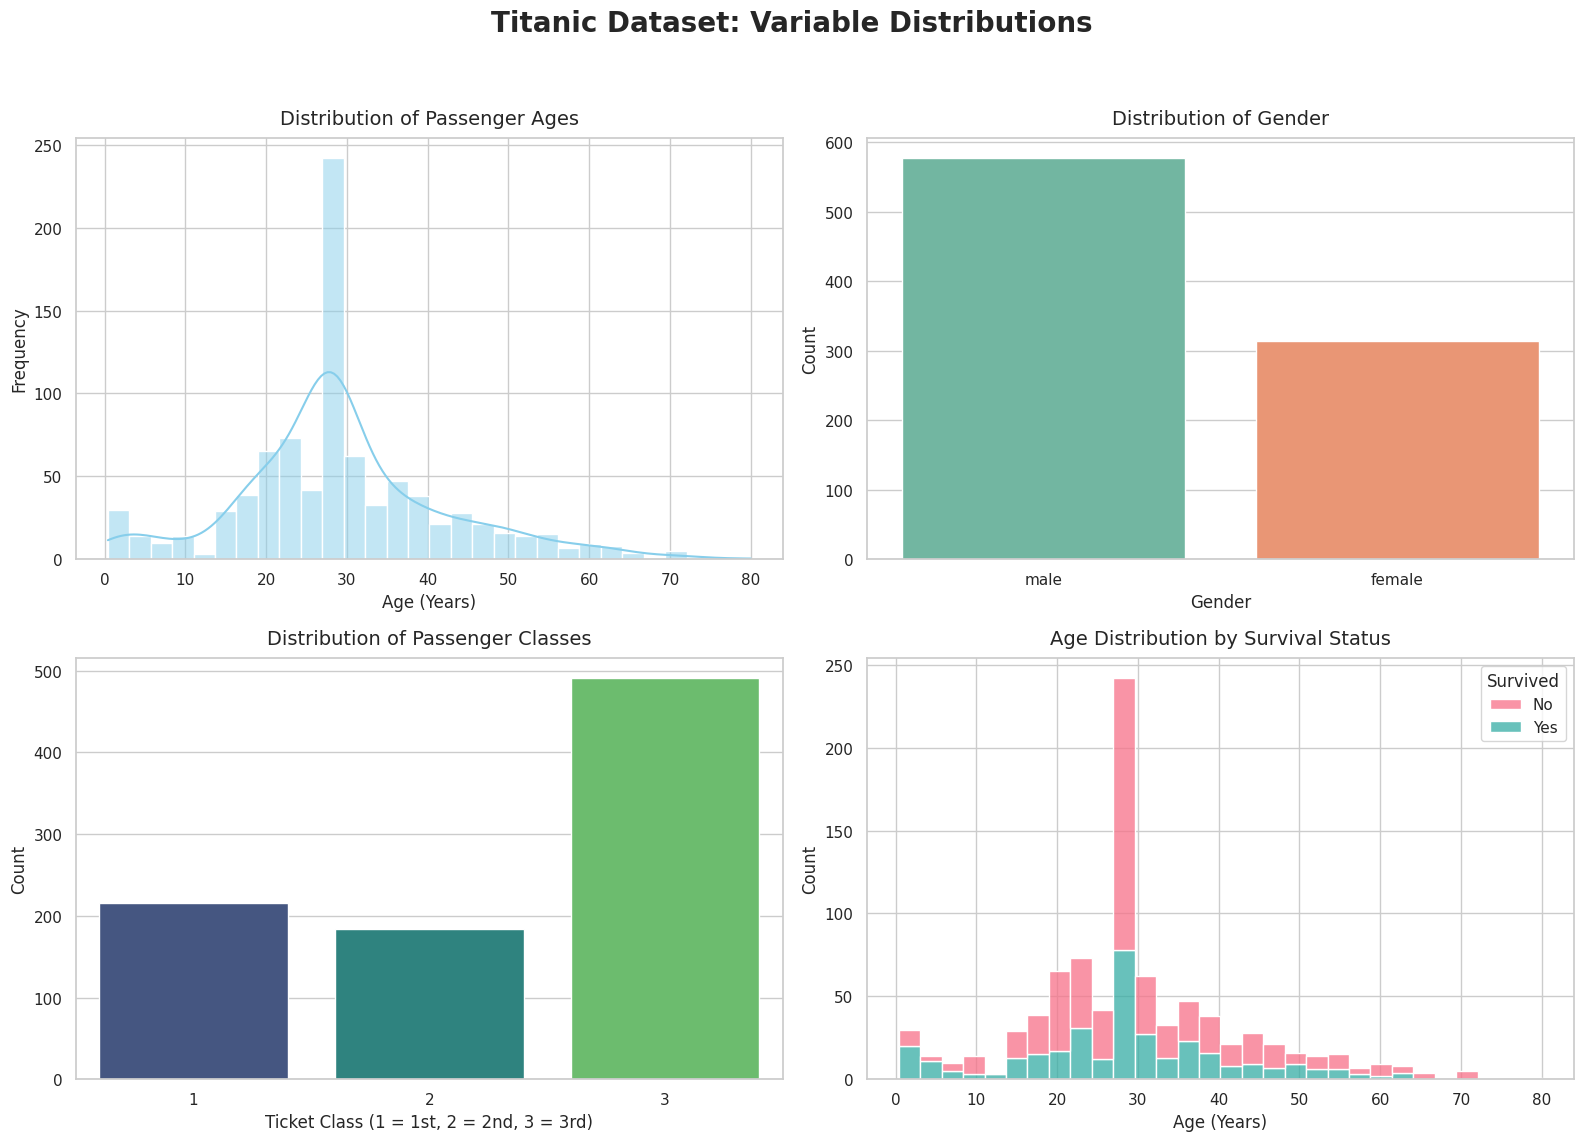

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# TASK 1: Data Distribution Visualization
# Dataset: Titanic Passenger Survival Data

def load_data(url):
    """Loads the dataset from the specified URL."""
    try:
        data = pd.read_csv(url)
        print("Dataset loaded successfully!")
        return data
    except Exception as e:
        print(f"Error loading data: {e}")
        return None

def clean_data(df):
    """Performs basic data cleaning and imputation."""
    print("Cleaning data...")
    cleaned_df = df.copy()


    median_age = cleaned_df['Age'].median()
    cleaned_df['Age'] = cleaned_df['Age'].fillna(median_age)

    mode_embarked = cleaned_df['Embarked'].mode()[0]
    cleaned_df['Embarked'] = cleaned_df['Embarked'].fillna(mode_embarked)

    return cleaned_df

def visualize_distributions(df):
    """Generates comprehensive histograms and bar charts for data distributions."""
    print("Generating visualizations...")

    sns.set_theme(style="whitegrid")

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Titanic Dataset: Variable Distributions', fontsize=20, fontweight='bold')

    sns.histplot(data=df, x='Age', bins=30, kde=True, color='skyblue', ax=axes[0, 0])
    axes[0, 0].set_title('Distribution of Passenger Ages', fontsize=14, pad=10)
    axes[0, 0].set_xlabel('Age (Years)', fontsize=12)
    axes[0, 0].set_ylabel('Frequency', fontsize=12)

    sns.countplot(data=df, x='Sex', palette='Set2', ax=axes[0, 1])
    axes[0, 1].set_title('Distribution of Gender', fontsize=14, pad=10)
    axes[0, 1].set_xlabel('Gender', fontsize=12)
    axes[0, 1].set_ylabel('Count', fontsize=12)

    sns.countplot(data=df, x='Pclass', palette='viridis', ax=axes[1, 0])
    axes[1, 0].set_title('Distribution of Passenger Classes', fontsize=14, pad=10)
    axes[1, 0].set_xlabel('Ticket Class (1 = 1st, 2 = 2nd, 3 = 3rd)', fontsize=12)
    axes[1, 0].set_ylabel('Count', fontsize=12)

    sns.histplot(data=df, x='Age', hue='Survived', multiple='stack', palette='husl', bins=30, ax=axes[1, 1])
    axes[1, 1].set_title('Age Distribution by Survival Status', fontsize=14, pad=10)
    axes[1, 1].set_xlabel('Age (Years)', fontsize=12)
    axes[1, 1].set_ylabel('Count', fontsize=12)

    legend = axes[1, 1].get_legend()
    if legend:
        legend.set_title('Survived')
        for t, l in zip(legend.texts, ['No', 'Yes']):
            t.set_text(l)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

def main():
    url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'

    # Execute the data pipeline
    df = load_data(url)

    if df is not None:
        cleaned_df = clean_data(df)
        visualize_distributions(cleaned_df)

# Entry point of the script
if __name__ == "__main__":
    main()